# DDSP Carnatic Vocals

Generate vocals from a pre-trained DDSP model given any pitch contour (f0 curve).

In [1]:
import os
import torch
import torch.nn.functional as F
import torchaudio
import torchcrepe
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from src.dataset import SAMPLE_RATE, HOP_LENGTH, CHUNK_SECONDS
from src.encoder import DDSPEncoder
from src.synth import DDSPSynth

device = torch.device("cuda" if torch.cuda.is_available() else "mps") # macos specific
print(f"Using device: {device}")

# Model checkpoint path
checkpoint_path = "output/encoder.pt"
print(f"Loading checkpoint from: {checkpoint_path}")

Using device: mps
Loading checkpoint from: output/encoder.pt


## Define Pitch Curve

In [2]:
def midi_to_hz(midi_note):
    """Convert MIDI note number to Hz."""
    return 440.0 * (2.0 ** ((midi_note - 69) / 12.0))

def hz_to_midi(hz):
    """Convert Hz to MIDI note number."""
    return 69 + 12 * np.log2(hz / 440.0)

def pitch_ramp(f0_start, f0_end, n_frames):
    """Linear pitch ramp from start to end frequency."""
    return np.linspace(f0_start, f0_end, n_frames)

def pitch_vibrato(f0_center, vibrato_hz=5.0, vibrato_cents=50, n_frames=None):
    """Add vibrato to a constant pitch."""
    if n_frames is None:
        n_frames = int(SAMPLE_RATE * 4.0 / HOP_LENGTH)  # default: 4 seconds
    t = np.arange(n_frames) / (SAMPLE_RATE / HOP_LENGTH)
    vibrato_semitones = vibrato_cents / 100.0
    return f0_center * (2.0 ** (vibrato_semitones * np.sin(2 * np.pi * vibrato_hz * t) / 12.0))

def pitch_from_notes(notes, note_duration_frames, n_frames=None):
    """Create pitch curve from a sequence of MIDI notes.
    """
    f0_list = []
    for midi_note in notes:
        f0_list.append(np.full(note_duration_frames, midi_to_hz(midi_note)))
    pitch = np.concatenate(f0_list)
    
    if n_frames is not None and len(pitch) < n_frames:
        pitch = np.pad(pitch, (0, n_frames - len(pitch)), mode='constant', constant_values=50.0)
    
    return pitch[:n_frames] if n_frames else pitch

In [8]:
pitch_source_path = "yaman-simple.wav"
n_frames = int(CHUNK_SECONDS * SAMPLE_RATE / HOP_LENGTH)


pitch_audio, pitch_sr = torchaudio.load(pitch_source_path)
if pitch_audio.shape[0] > 1:
    pitch_audio = pitch_audio.mean(dim=0, keepdim=True)
if pitch_sr != SAMPLE_RATE:
    pitch_audio = torchaudio.transforms.Resample(pitch_sr, SAMPLE_RATE)(pitch_audio)
pitch_audio = pitch_audio.squeeze(0)

# Calculate n_frames based on actual audio length, not fixed CHUNK_SECONDS
n_frames = (len(pitch_audio) + HOP_LENGTH - 1) // HOP_LENGTH
chunk_len = n_frames * HOP_LENGTH

# Pad if needed to align to hop boundary
if len(pitch_audio) < chunk_len:
    pitch_audio = torch.nn.functional.pad(pitch_audio, (0, chunk_len - len(pitch_audio)))

pitch_curve, _ = torchcrepe.predict(
    pitch_audio.unsqueeze(0),
    sample_rate=SAMPLE_RATE,
    hop_length=HOP_LENGTH,
    fmin=80.0,
    fmax=2500.0,
    model="full",
    batch_size=1024,
    device=str(device),
    return_periodicity=True,
)
pitch_curve = pitch_curve.squeeze(0).numpy()
if len(pitch_curve) < n_frames:
    pitch_curve = np.pad(pitch_curve, (0, n_frames - len(pitch_curve)), mode="edge")
pitch_curve = pitch_curve[:n_frames]
print(f"Pitch curve extracted from {pitch_source_path!r}: {pitch_curve.shape}, "
      f"f0 range: {pitch_curve.min():.1f} - {pitch_curve.max():.1f} Hz")

Pitch curve extracted from 'yaman-simple.wav': (576,), f0 range: 308.9 - 667.2 Hz


## Load Pre-trained DDSP Models

In [9]:
# Initialize models
encoder = DDSPEncoder(sample_rate=SAMPLE_RATE, hop_length=HOP_LENGTH).to(device)
synth = DDSPSynth(sample_rate=SAMPLE_RATE, hop_length=HOP_LENGTH).to(device)

# Load checkpoint
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    encoder.load_state_dict(checkpoint["encoder"])
    synth.load_state_dict(checkpoint["synth"])
    print(f"✓ Loaded models from {checkpoint_path}")
else:
    print(f"✗ Checkpoint not found at {checkpoint_path}")
    print(f"  Please train a model first using train.py")

encoder.eval()
synth.eval()

✓ Loaded models from output/encoder.pt


DDSPSynth(
  (harmonic): HarmonicOscillator()
  (noise): FilteredNoiseSynth()
  (reverb): TrainableFIRReverb()
)

## Generate Vocal Audio from Pitch Curve

In [13]:
reference_audio_path = "audio/Alamelu Manga_A_chunk1.mp3"  # a vocal clip from the training set

print(f"\n=== Loading reference audio from {reference_audio_path} ===")
ref_audio, sr = torchaudio.load(reference_audio_path)

# Preprocess to match training
if ref_audio.shape[0] > 1:
    ref_audio = ref_audio.mean(dim=0, keepdim=True)
if sr != SAMPLE_RATE:
    ref_audio = torchaudio.transforms.Resample(sr, SAMPLE_RATE)(ref_audio)
ref_audio = ref_audio.squeeze(0)

# Calculate n_frames based on actual audio length, not fixed CHUNK_SECONDS
n_frames = (len(ref_audio) + HOP_LENGTH - 1) // HOP_LENGTH
chunk_len = n_frames * HOP_LENGTH

# Pad if needed to align to hop boundary
if len(pitch_audio) < chunk_len:
    pitch_audio = torch.nn.functional.pad(pitch_audio, (0, chunk_len - len(pitch_audio)))

# Normalize
peak = ref_audio.abs().max().clamp(min=1e-8)
ref_audio = ref_audio / peak * 0.9

# Extract timbre from reference with its own pitch (we'll re-pitch to the new contour below)
ref_audio_batch = ref_audio.unsqueeze(0).to(device)
ref_f0, _ = torchcrepe.predict(
    ref_audio_batch,
    sample_rate=SAMPLE_RATE,
    hop_length=HOP_LENGTH,
    fmin=80.0,
    fmax=1000.0,
    model="full",
    batch_size=1024,
    device=str(device),
    return_periodicity=True,
)
ref_f0 = ref_f0.squeeze(0).cpu().numpy()
print(f"✓ Extracted reference f0: {ref_f0.min():.1f} - {ref_f0.max():.1f} Hz")

# Encode timbre from reference (pad/truncate ref_f0 to match ref_audio's frame count)
ref_n_frames = len(ref_audio) // HOP_LENGTH
if len(ref_f0) < ref_n_frames:
    ref_f0 = np.pad(ref_f0, (0, ref_n_frames - len(ref_f0)), mode="edge")
ref_f0 = ref_f0[:ref_n_frames]

with torch.no_grad():
    ref_controls = encoder(
        ref_audio.unsqueeze(0).to(device),
        torch.from_numpy(ref_f0).unsqueeze(0).to(device).float(),
    )

print(f"✓ Extracted timbre from reference audio")


=== Loading reference audio from audio/Alamelu Manga_A_chunk1.mp3 ===
✓ Extracted reference f0: 198.3 - 481.5 Hz
✓ Extracted timbre from reference audio


In [14]:
# Synthesize with new pitch curve
print(f"Pitch curve: {len(pitch_curve)} frames ({len(pitch_curve) * HOP_LENGTH / SAMPLE_RATE:.2f}s)")
print(f"F0 range: {pitch_curve.min():.1f} - {pitch_curve.max():.1f} Hz")

n_samples = len(pitch_curve) * HOP_LENGTH
pitch_curve_t = torch.from_numpy(pitch_curve).unsqueeze(0).to(device).float()

# Use timbre from reference, but pitch from the new curve
controls = {
    "f0_hz": pitch_curve_t,
    "amplitude": ref_controls["amplitude"],
    "harmonic_distribution": ref_controls["harmonic_distribution"],
    "noise_magnitudes": ref_controls["noise_magnitudes"],
}
print("Using timbre from reference audio with new pitch curve")

# Generate!
with torch.no_grad():
    generated_audio = synth(controls, n_samples=n_samples)

generated_audio = generated_audio.squeeze(0).cpu().numpy()

Pitch curve: 576 frames (9.22s)
F0 range: 308.9 - 667.2 Hz
Using timbre from reference audio with new pitch curve


## Visualize Pitch Curve and Generated Audio

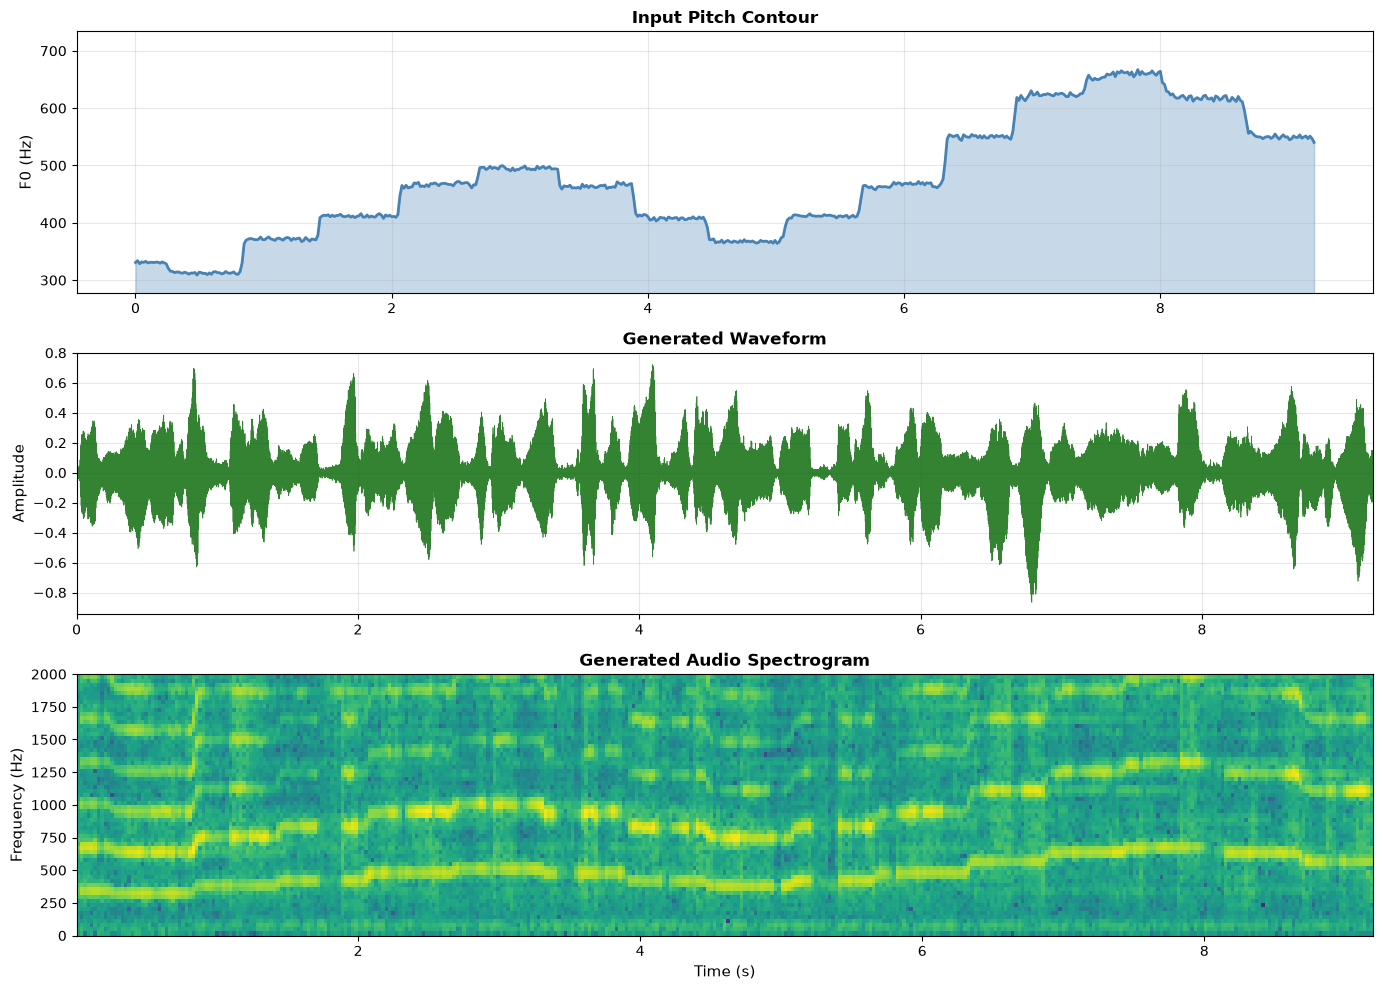

Generated audio duration: 9.22s

Original Audio:


Generated Audio:


In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot Pitch curve
t_frames = np.arange(len(pitch_curve)) * HOP_LENGTH / SAMPLE_RATE
axes[0].plot(t_frames, pitch_curve, linewidth=2, color='steelblue')
axes[0].fill_between(t_frames, pitch_curve, alpha=0.3, color='steelblue')
axes[0].set_ylabel("F0 (Hz)", fontsize=11)
axes[0].set_title("Input Pitch Contour", fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(pitch_curve.min() * 0.9, pitch_curve.max() * 1.1)

# Plot Waveform
t_samples = np.arange(len(generated_audio)) / SAMPLE_RATE
axes[1].plot(t_samples, generated_audio, linewidth=0.5, color='darkgreen', alpha=0.8)
axes[1].set_ylabel("Amplitude", fontsize=11)
axes[1].set_title("Generated Waveform", fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, t_samples[-1])

# Plot Spectrogram
axes[2].specgram(
    generated_audio,
    Fs=SAMPLE_RATE,
    NFFT=512,
    cmap='viridis',
)
axes[2].set_ylabel("Frequency (Hz)", fontsize=11)
axes[2].set_xlabel("Time (s)", fontsize=11)
axes[2].set_title("Generated Audio Spectrogram", fontsize=12, fontweight='bold')
axes[2].set_ylim(0, 2000)

plt.tight_layout()
plt.show()

print(f"Generated audio duration: {len(generated_audio) / SAMPLE_RATE:.2f}s\n")

# Play the generated audio
print("Original Audio:")
display(Audio(pitch_source_path, rate=SAMPLE_RATE))

# Play the generated audio
print("Generated Audio:")
display(Audio(generated_audio, rate=SAMPLE_RATE))